<a href="https://colab.research.google.com/github/aninsung/AI-study/blob/main/unet_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split


# 하이퍼파라미터
batch_size = 4
num_epochs = 50
learning_rate = 1e-4

#이미지 경로
train_image_dir = '/content/drive/MyDrive/archive/CHASE_DB1/Images'
train_mask_dir = '/content/drive/MyDrive/archive/CHASE_DB1/Masks'

In [22]:
class RetinalDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_name = self.images[index]
        img_path = os.path.join(self.image_dir, image_name)

        # 파일 이름 규칙 (1stHO.png 우선 검색)
        base_name = os.path.splitext(image_name)[0]
        mask_path = os.path.join(self.mask_dir, f"{base_name}_1stHO.png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{base_name}_2ndHO.png")

        # 이미지 읽기
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.image_size, self.image_size))

        # 마스크 읽기
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"마스크를 찾을 수 없습니다: {mask_path}")
        mask = cv2.resize(mask, (self.image_size, self.image_size))

        # 정규화 및 텐서 변환
        image = image / 255.0
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)

        image = np.transpose(image, (2, 0, 1))
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [23]:

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x = self.conv1(torch.cat([x3, self.up1(x4)], dim=1))
        x = self.conv2(torch.cat([x2, self.up2(x)], dim=1))
        x = self.conv3(torch.cat([x1, self.up3(x)], dim=1))

        return self.out(x)

In [24]:
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')
        inputs = torch.sigmoid(inputs).view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        return BCE + dice_loss

def calculate_dice_score(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    dice = (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)
    return dice.item()

In [25]:
if not os.path.exists(train_image_dir) or not os.path.exists(train_mask_dir):
    print("설정된 경로에 폴더가 없습니다. [Cell 1]의 경로를 다시 확인해주세요.")
else:
    full_dataset = RetinalDataset(image_dir=train_image_dir, mask_dir=train_mask_dir)
    dataset_size = len(full_dataset)
    val_size = int(dataset_size * 0.2)
    train_size = dataset_size - val_size

    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"데이터 준비 완료: 총 {dataset_size}개 (학습용 {train_size}개 | 검증용 {val_size}개)")

데이터 준비 완료: 총 28개 (학습용 23개 | 검증용 5개)


In [26]:
# 모델 설정
model = UNet(in_channels=3, out_channels=1).to(device)
criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
best_val_loss = float('inf')
best_model_path = '/content/best_unet_model.pth'


for epoch in range(num_epochs):
    # [Train Phase]
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            val_dice += calculate_dice_score(outputs, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

    # [Checkpointing]
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f" Best Model Saved (Val Loss improved to {best_val_loss:.4f})")


Epoch [01/50] Train Loss: 1.5589 | Val Loss: 1.6366 | Val Dice: 0.1267
 Best Model Saved (Val Loss improved to 1.6366)
Epoch [02/50] Train Loss: 1.4481 | Val Loss: 1.6450 | Val Dice: 0.1267
Epoch [03/50] Train Loss: 1.3680 | Val Loss: 1.6042 | Val Dice: 0.1280
 Best Model Saved (Val Loss improved to 1.6042)
Epoch [04/50] Train Loss: 1.3124 | Val Loss: 1.4907 | Val Dice: 0.0018
 Best Model Saved (Val Loss improved to 1.4907)
Epoch [05/50] Train Loss: 1.2691 | Val Loss: 1.3769 | Val Dice: 0.0013
 Best Model Saved (Val Loss improved to 1.3769)
Epoch [06/50] Train Loss: 1.2369 | Val Loss: 1.3099 | Val Dice: 0.0055
 Best Model Saved (Val Loss improved to 1.3099)
Epoch [07/50] Train Loss: 1.2113 | Val Loss: 1.2572 | Val Dice: 0.1105
 Best Model Saved (Val Loss improved to 1.2572)
Epoch [08/50] Train Loss: 1.1886 | Val Loss: 1.2299 | Val Dice: 0.4229
 Best Model Saved (Val Loss improved to 1.2299)
Epoch [09/50] Train Loss: 1.1662 | Val Loss: 1.1828 | Val Dice: 0.5487
 Best Model Saved (Val Lo

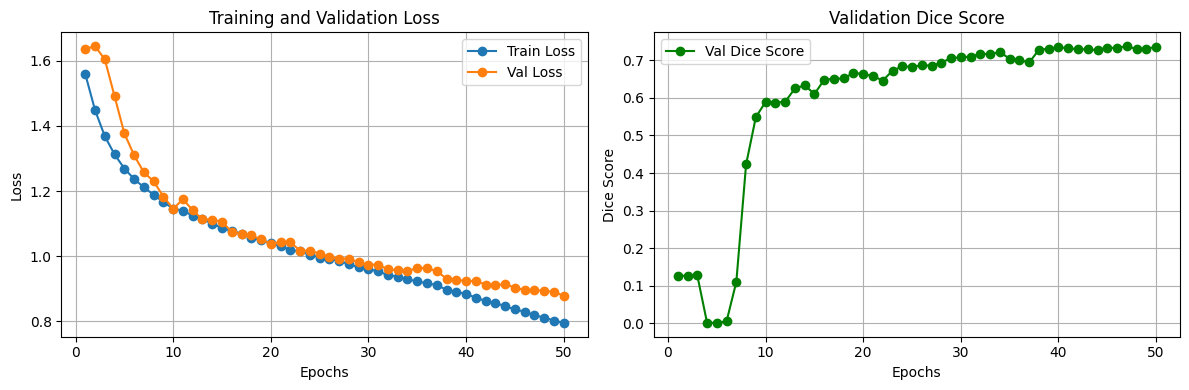

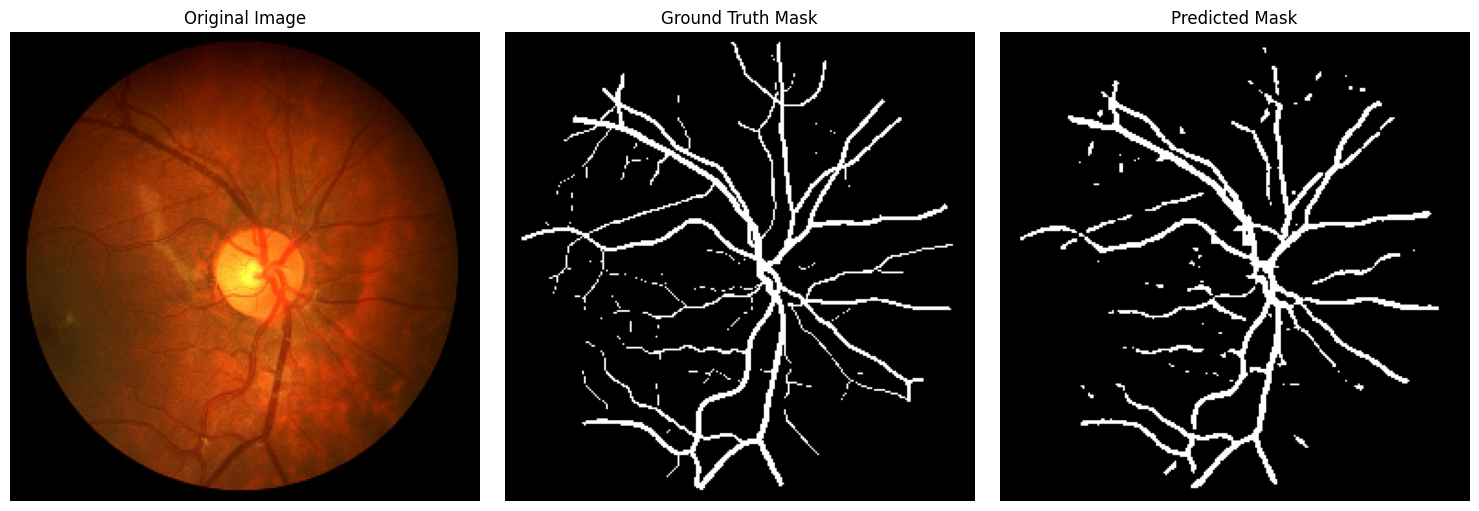

In [27]:
#  학습 곡선 (Loss & Dice Score) 시각화
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_dice'], label='Val Dice Score', color='green', marker='o')
plt.title('Validation Dice Score')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) 예측 결과 시각화 (원본 이미지 vs 실제 정답 vs AI 예측)
# 가장 성능이 좋았던 모델 불러오기
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 검증 데이터셋에서 배치 하나 가져오기
images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = (torch.sigmoid(outputs) > 0.5).float() # 예측값을 0 또는 1로 변환

# 텐서를 넘파이 배열로 변환
images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

# 첫 번째 이미지(인덱스 0) 표시
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 원본 (CHW -> HWC)
axes[0].imshow(np.transpose(images[0], (1, 2, 0)))
axes[0].set_title("Original Image")
axes[0].axis("off")

# 정답 (Ground Truth)
axes[1].imshow(masks[0][0], cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

# AI 예측 결과
axes[2].imshow(preds[0][0], cmap='gray')
axes[2].set_title("Predicted Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()